<a href="https://colab.research.google.com/github/elias8080007/Syntecxhub_Sentiment_Analysis_Tool/blob/main/sentiment_analysis_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis Tool

Syntecxhub Artificial Intelligence Internship  
Week 2 Project  
Developed by Elias Ibrahim Elias

## 1. Project Overview

This project develops a natural-language processing system that classifies text according to its sentiment.

The system processes labeled tweets and predicts one of three sentiment classes:

- Positive
- Neutral
- Negative

The project uses TF-IDF to convert text into numerical features. Naive Bayes and Logistic Regression will then be trained and compared to select the strongest classification model.

## 2. Project Objectives

- Load and examine a labeled sentiment dataset.
- Identify missing values, duplicate records, and class imbalance.
- Clean and preprocess social-media text.
- Convert text into numerical TF-IDF features.
- Train Naive Bayes and Logistic Regression classifiers.
- Evaluate both models using multiple classification metrics.
- Select the strongest model based on test-set performance.
- Analyze incorrect predictions and model limitations.
- Create an interactive tool for predicting custom text.
- Save the trained pipeline for future use.

## 3. Sentiment Labels

The target classes are:

- Positive: The text expresses satisfaction, praise, or a favorable opinion.
- Neutral: The text expresses information without a clearly positive or negative opinion.
- Negative: The text expresses dissatisfaction, criticism, or an unfavorable opinion.

## 4. Project Workflow

Labeled Text Dataset  
→ Data Validation  
→ Exploratory Data Analysis  
→ Text Preprocessing  
→ Train and Test Split  
→ TF-IDF Vectorization  
→ Model Training  
→ Model Evaluation  
→ Error Analysis  
→ Interactive Prediction Tool

## 5. Technologies

- Python
- Google Colab
- pandas
- NumPy
- Matplotlib
- Seaborn
- scikit-learn
- Natural Language Processing
- TF-IDF
- Logistic Regression
- Naive Bayes

## 6. Dataset Description

The Twitter US Airline Sentiment dataset contains tweets directed at six major American airlines.

Each tweet is labeled using one of three sentiment classes:

- Positive
- Neutral
- Negative

The primary columns used in this project are:

- `text`: The original tweet.
- `airline_sentiment`: The assigned sentiment label.
- `airline`: The airline mentioned in the tweet.
- `airline_sentiment_confidence`: The confidence of the assigned label.

Dataset source: Twitter US Airline Sentiment on Kaggle.

## 7. Importing the Required Libraries

The project uses pandas and NumPy for data processing, Matplotlib and Seaborn for visualization, and scikit-learn for text vectorization, model training, and evaluation.

In [1]:
import re
import string
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline


warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

pd.set_option(
    "display.max_colwidth",
    150
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 8. Uploading the Dataset

The CSV dataset is uploaded to the current Colab session and prepared for inspection.

In [2]:
from google.colab import files


uploaded_files = files.upload()

Saving Tweets.csv to Tweets.csv


## 9. Loading the Dataset

The uploaded CSV file is loaded into a pandas DataFrame. The first records are displayed to verify that the file was read correctly.

In [3]:
csv_files = list(
    Path("/content").glob("*.csv")
)

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found. Please upload Tweets.csv."
    )

dataset_path = next(
    (
        file_path
        for file_path in csv_files
        if file_path.name.lower() == "tweets.csv"
    ),
    csv_files[0]
)

dataset = pd.read_csv(
    dataset_path
)

print("Dataset loaded successfully.")
print("Dataset file:", dataset_path.name)
print("Dataset dimensions:", dataset.shape)

display(
    dataset.head()
)

Dataset loaded successfully.
Dataset file: Tweets.csv
Dataset dimensions: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 10. Selecting the Relevant Features

Only the columns needed for sentiment analysis and basic exploration are retained.

The text column will be used as the model input, while the airline sentiment column will be used as the prediction target.

In [4]:
required_columns = [
    "text",
    "airline_sentiment",
    "airline",
    "airline_sentiment_confidence"
]

missing_columns = [
    column
    for column in required_columns
    if column not in dataset.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

sentiment_data = dataset[
    required_columns
].copy()

sentiment_data = sentiment_data.rename(
    columns={
        "airline_sentiment": "sentiment",
        "airline_sentiment_confidence": "sentiment_confidence"
    }
)

print("Selected dataset dimensions:", sentiment_data.shape)

display(
    sentiment_data.head()
)

Selected dataset dimensions: (14640, 4)


,text,sentiment,airline,sentiment_confidence
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America,1.0000
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive,Virgin America,0.3486
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral,Virgin America,0.6837
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative,Virgin America,1.0000
4,@VirginAmerica and it's a really big bad thing about it,negative,Virgin America,1.0000


## 11. Initial Data Quality Assessment

Before preprocessing, the dataset is examined for missing values, duplicate tweets, unexpected labels, and incorrect data types.

This prevents invalid records from affecting the exploratory analysis or machine-learning models.

In [5]:
print("Data types and non-null values:\n")

sentiment_data.info()

print("\nMissing values:")
display(
    sentiment_data.isnull().sum().to_frame(
        name="Missing Values"
    )
)

duplicate_tweets = sentiment_data.duplicated(
    subset="text"
).sum()

available_labels = sorted(
    sentiment_data["sentiment"]
    .dropna()
    .astype(str)
    .str.lower()
    .unique()
)

print("Number of duplicate tweets:", duplicate_tweets)
print("Available sentiment labels:", available_labels)

print("\nSentiment counts:")
display(
    sentiment_data["sentiment"]
    .value_counts(dropna=False)
    .to_frame(name="Number of Tweets")
)

print("\nRandom dataset examples:")
display(
    sentiment_data.sample(
        5,
        random_state=RANDOM_STATE
    )
)

Data types and non-null values:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   text                  14640 non-null  object 
 1   sentiment             14640 non-null  object 
 2   airline               14640 non-null  object 
 3   sentiment_confidence  14640 non-null  float64
dtypes: float64(1), object(3)
memory usage: 457.6+ KB

Missing values:


,Missing Values
text,0
sentiment,0
airline,0
sentiment_confidence,0


Number of duplicate tweets: 213
Available sentiment labels: ['negative', 'neutral', 'positive']

Sentiment counts:


,Number of Tweets
sentiment,
negative,9178
neutral,3099
positive,2363



Random dataset examples:


,text,sentiment,airline,sentiment_confidence
4794,@SouthwestAir you're my early frontrunner for best airline! #oscars2016,positive,Southwest,1.0000
10480,@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?,negative,US Airways,1.0000
8067,@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?,negative,Delta,1.0000
8880,"@JetBlue do they have to depart from Washington, D.C.??",neutral,Delta,1.0000
8292,@JetBlue I can probably find some of them. Are the ticket #s on there?,negative,Delta,0.6625


## 12. Duplicate Tweet Analysis

The dataset contains repeated tweet text. Duplicate groups are examined before removal to determine whether the repeated tweets have consistent or conflicting sentiment labels.

In [6]:
duplicate_rows = sentiment_data[
    sentiment_data.duplicated(
        subset="text",
        keep=False
    )
].copy()

duplicate_summary = (
    duplicate_rows
    .groupby("text")
    .agg(
        record_count=("text", "size"),
        sentiment_count=("sentiment", "nunique"),
        sentiments=(
            "sentiment",
            lambda values: ", ".join(
                sorted(set(values))
            )
        ),
        maximum_confidence=(
            "sentiment_confidence",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        by="record_count",
        ascending=False
    )
)

conflicting_duplicates = duplicate_summary[
    duplicate_summary["sentiment_count"] > 1
]

print(
    "Records involved in duplicate groups:",
    len(duplicate_rows)
)

print(
    "Number of repeated-text groups:",
    len(duplicate_summary)
)

print(
    "Groups with conflicting labels:",
    len(conflicting_duplicates)
)

print("\nExamples of duplicate groups:")

display(
    duplicate_summary.head(10)
)

if not conflicting_duplicates.empty:
    print("\nExamples with conflicting sentiment labels:")

    display(
        conflicting_duplicates.head(10)
    )

Records involved in duplicate groups: 400
Number of repeated-text groups: 187
Groups with conflicting labels: 25

Examples of duplicate groups:


,text,record_count,sentiment_count,sentiments,maximum_confidence
182,@united thanks,6,2,"neutral, positive",1.0
162,@SouthwestAir sent,5,1,neutral,1.0
127,@AmericanAir thanks,5,1,positive,1.0
158,@JetBlue thanks!,5,1,positive,1.0
126,@AmericanAir thank you!,4,1,positive,1.0
180,@united thank you!,4,1,positive,1.0
167,@USAirways YOU ARE THE BEST!!! FOLLOW ME PLEASE;)🙏🙏🙏✌️✌️✌️🙏🙏🙏,3,1,positive,1.0
176,@united Thanks!,3,1,positive,1.0
169,@USAirways thanks,3,1,positive,1.0
132,@AmericanAir thanks!,3,2,"neutral, positive",1.0



Examples with conflicting sentiment labels:


,text,record_count,sentiment_count,sentiments,maximum_confidence
182,@united thanks,6,2,"neutral, positive",1.0000
132,@AmericanAir thanks!,3,2,"neutral, positive",1.0000
168,@USAirways thank you,3,2,"neutral, positive",1.0000
159,@SouthwestAir Thank you!,3,2,"neutral, positive",1.0000
11,@AmericanAir @Clarkey_19 we done it with 1 truck... No biggie 😄,2,2,"neutral, positive",1.0000
7,@AmericanAir - keeping AA up in the Air! My crew chief cousin Alex Espinosa in DFW! http://t.co/0HXLNvZknP,2,2,"neutral, positive",1.0000
33,@AmericanAir I don't think you should help him at all based on his behavior. The voucher and cot seem like enough lol 😃,2,2,"neutral, positive",0.7012
36,@AmericanAir I might look into that. My wife travels much more than I do. Could we both use the membership?,2,2,"neutral, positive",1.0000
12,"@AmericanAir @RobertDwyer AA doesnt charge any fees to change award tickets as long as the origin, destination &amp; award type remains the same",2,2,"neutral, positive",0.6808
21,"@AmericanAir Believe me, I understand. Flight #2955. Was originally booked for Sunday. Flight was Cancelled Flighted and rescheduled for today.",2,2,"negative, positive",0.6604


## 13. Dataset Cleaning

The dataset is cleaned by standardizing sentiment labels, removing empty text, validating the target classes, and resolving duplicate tweets.

When duplicate text has multiple records, the entry with the highest sentiment confidence is retained.

In [7]:
clean_data = sentiment_data.copy()

initial_row_count = len(clean_data)

clean_data["text"] = (
    clean_data["text"]
    .astype(str)
    .str.strip()
)

clean_data["sentiment"] = (
    clean_data["sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

clean_data["airline"] = (
    clean_data["airline"]
    .astype(str)
    .str.strip()
)

valid_sentiments = {
    "negative",
    "neutral",
    "positive"
}

clean_data = clean_data[
    clean_data["text"].str.len() > 0
]

clean_data = clean_data[
    clean_data["sentiment"].isin(
        valid_sentiments
    )
]

clean_data = (
    clean_data
    .sort_values(
        by="sentiment_confidence",
        ascending=False
    )
    .drop_duplicates(
        subset="text",
        keep="first"
    )
    .reset_index(drop=True)
)

final_row_count = len(clean_data)
removed_row_count = initial_row_count - final_row_count

print("Original number of rows:", initial_row_count)
print("Cleaned number of rows:", final_row_count)
print("Removed rows:", removed_row_count)

print(
    "Remaining duplicate tweets:",
    clean_data.duplicated(
        subset="text"
    ).sum()
)

print(
    "Remaining missing values:",
    clean_data.isnull().sum().sum()
)

print(
    "Final sentiment labels:",
    sorted(
        clean_data["sentiment"].unique()
    )
)

Original number of rows: 14640
Cleaned number of rows: 14427
Removed rows: 213
Remaining duplicate tweets: 0
Remaining missing values: 0
Final sentiment labels: ['negative', 'neutral', 'positive']


## 14. Sentiment Class Distribution

The sentiment distribution is examined using counts and percentages.

This analysis identifies class imbalance and helps determine which evaluation metrics and training strategies should be used.

,Sentiment,Count,Percentage
0,negative,9082,62.95%
1,neutral,3055,21.18%
2,positive,2290,15.87%


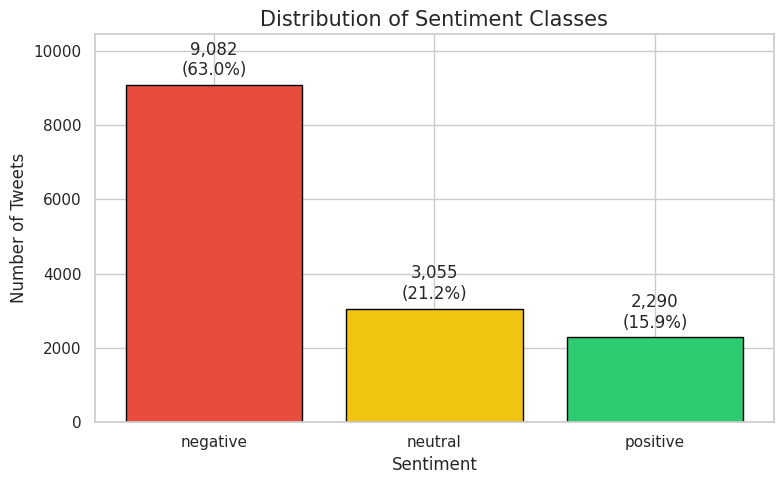

In [8]:
sentiment_order = [
    "negative",
    "neutral",
    "positive"
]

sentiment_colors = {
    "negative": "#E74C3C",
    "neutral": "#F1C40F",
    "positive": "#2ECC71"
}

sentiment_counts = (
    clean_data["sentiment"]
    .value_counts()
    .reindex(sentiment_order)
)

sentiment_percentages = (
    sentiment_counts
    / sentiment_counts.sum()
    * 100
)

sentiment_distribution = pd.DataFrame({
    "Sentiment": sentiment_order,
    "Count": sentiment_counts.values,
    "Percentage": sentiment_percentages.values
})

display(
    sentiment_distribution.style.format({
        "Percentage": "{:.2f}%"
    })
)

figure, axis = plt.subplots(
    figsize=(8, 5)
)

bars = axis.bar(
    sentiment_distribution["Sentiment"],
    sentiment_distribution["Count"],
    color=[
        sentiment_colors[label]
        for label in sentiment_order
    ],
    edgecolor="black"
)

axis.bar_label(
    bars,
    labels=[
        f"{count:,}\n({percentage:.1f}%)"
        for count, percentage in zip(
            sentiment_distribution["Count"],
            sentiment_distribution["Percentage"]
        )
    ],
    padding=4
)

axis.set_title(
    "Distribution of Sentiment Classes",
    fontsize=15
)

axis.set_xlabel("Sentiment")
axis.set_ylabel("Number of Tweets")

axis.set_ylim(
    0,
    sentiment_distribution["Count"].max() * 1.15
)

plt.tight_layout()

plt.savefig(
    "/content/sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Tweet Length Analysis

Tweet length is examined to understand how much textual information is available to the classifier and whether length differs across sentiment classes.

character_count                 word_count               
                     mean median min  max       mean median min max
sentiment                                                          
negative           113.94  126.0  12  176      19.69   21.0   2  36
neutral             87.67   88.0  12  167      14.46   14.0   2  31
positive            87.39   87.0  12  186      14.24   14.0   2  31

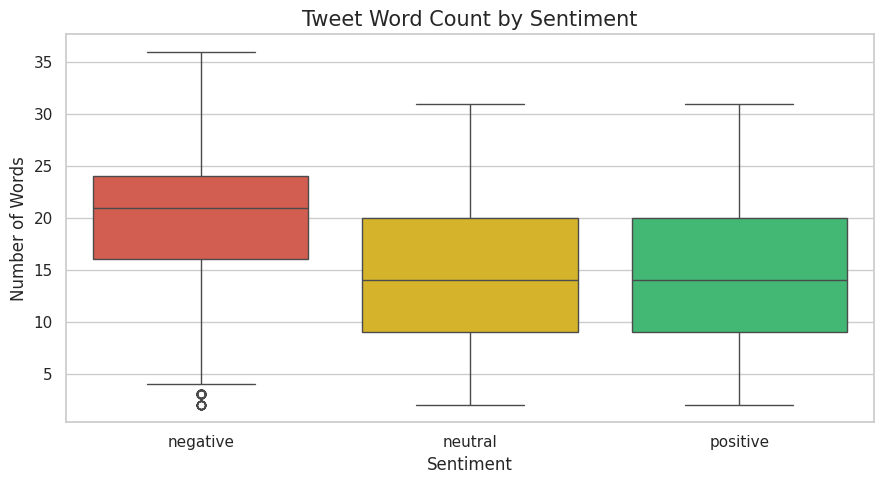

In [9]:
clean_data["character_count"] = (
    clean_data["text"].str.len()
)

clean_data["word_count"] = (
    clean_data["text"]
    .str.split()
    .str.len()
)

length_summary = (
    clean_data
    .groupby("sentiment")[
        [
            "character_count",
            "word_count"
        ]
    ]
    .agg([
        "mean",
        "median",
        "min",
        "max"
    ])
    .round(2)
    .reindex(sentiment_order)
)

display(
    length_summary
)

figure, axis = plt.subplots(
    figsize=(9, 5)
)

sns.boxplot(
    data=clean_data,
    x="sentiment",
    y="word_count",
    order=sentiment_order,
    palette=sentiment_colors,
    hue="sentiment",
    legend=False,
    ax=axis
)

axis.set_title(
    "Tweet Word Count by Sentiment",
    fontsize=15
)

axis.set_xlabel("Sentiment")
axis.set_ylabel("Number of Words")

plt.tight_layout()

plt.savefig(
    "/content/tweet_length_by_sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

After removing 213 duplicate tweets, the cleaned dataset contains 14,427 unique records.

Negative sentiment is the dominant class with 9,082 tweets, representing approximately 62.95% of the dataset. Neutral sentiment contains 3,055 tweets, or 21.18%, while positive sentiment is the smallest class with 2,290 tweets, or 15.87%.

This distribution reveals a noticeable class imbalance. Therefore, accuracy alone will not be sufficient for evaluating the models. Macro F1-score, class-level precision and recall, and the confusion matrix will also be used. Stratified data splitting will preserve these class proportions across the training, validation, and test sets.

## 16. Sentiment Distribution by Airline

The sentiment proportions are calculated separately for each airline.

Percentages are used instead of raw counts so airlines with different numbers of tweets can be compared fairly.

sentiment,negative,neutral,positive
airline,,,
US Airways,77.84%,13.08%,9.08%
American,71.94%,16.58%,11.49%
United,69.20%,18.21%,12.59%
Southwest,49.21%,27.33%,23.46%
Delta,43.19%,32.70%,24.11%
Virgin America,35.98%,34.00%,30.02%


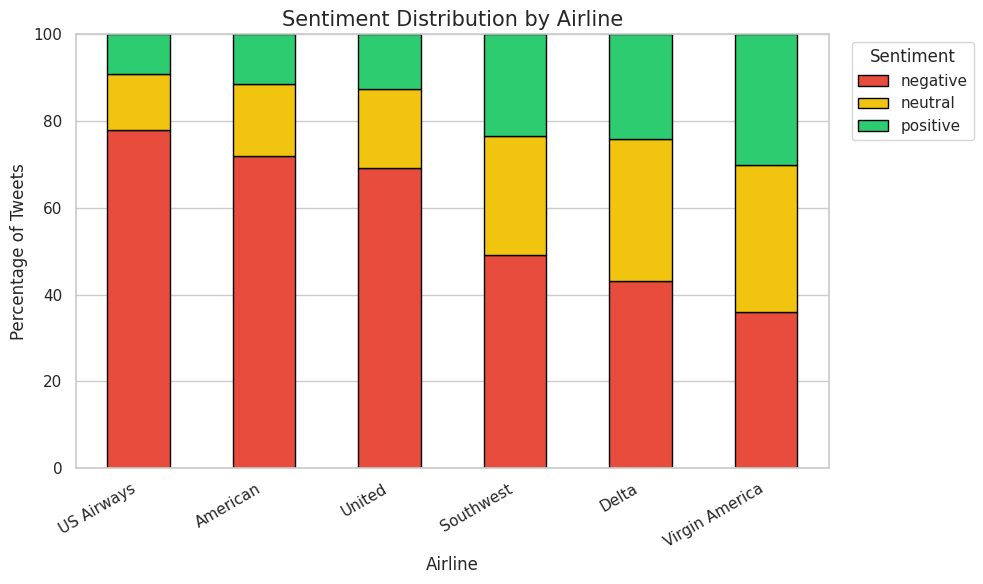

In [10]:
airline_sentiment_percentages = (
    pd.crosstab(
        clean_data["airline"],
        clean_data["sentiment"],
        normalize="index"
    )
    .mul(100)
    .reindex(columns=sentiment_order)
    .sort_values(
        by="negative",
        ascending=False
    )
)

display(
    airline_sentiment_percentages.style.format(
        "{:.2f}%"
    )
)

axis = airline_sentiment_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[
        sentiment_colors[label]
        for label in sentiment_order
    ],
    edgecolor="black"
)

axis.set_title(
    "Sentiment Distribution by Airline",
    fontsize=15
)

axis.set_xlabel("Airline")
axis.set_ylabel("Percentage of Tweets")
axis.set_ylim(0, 100)

axis.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "/content/sentiment_by_airline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Text Preprocessing

Social-media text may contain URLs, user mentions, hashtags, punctuation, inconsistent capitalization, and unnecessary spacing.

The preprocessing function removes noisy elements while preserving meaningful words and negation expressions that may affect sentiment.

In [11]:
def clean_text(text):
    text = str(text).lower().strip()

    text = text.replace("’", "'")

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    text = re.sub(
        r"@\w+",
        " ",
        text
    )

    text = re.sub(
        r"#(\w+)",
        r"\1",
        text
    )

    text = re.sub(
        r"\bwon't\b",
        "will not",
        text
    )

    text = re.sub(
        r"\bcan't\b",
        "cannot",
        text
    )

    text = re.sub(
        r"n't\b",
        " not",
        text
    )

    text = re.sub(
        r"'re\b",
        " are",
        text
    )

    text = re.sub(
        r"'m\b",
        " am",
        text
    )

    text = re.sub(
        r"'ll\b",
        " will",
        text
    )

    text = re.sub(
        r"'ve\b",
        " have",
        text
    )

    text = re.sub(
        r"'d\b",
        " would",
        text
    )

    text = re.sub(
        r"'s\b",
        "",
        text
    )

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


clean_data["cleaned_text"] = (
    clean_data["text"].apply(clean_text)
)

empty_cleaned_text = (
    clean_data["cleaned_text"].str.len() == 0
).sum()

print(
    "Empty records after text cleaning:",
    empty_cleaned_text
)

print(
    "Text preprocessing completed successfully."
)

Empty records after text cleaning: 0
Text preprocessing completed successfully.


## 18. Original and Preprocessed Text Comparison

A sample of original and cleaned tweets is displayed to verify that noisy elements were removed without losing the main sentiment information.

In [12]:
text_comparison = (
    clean_data[
        [
            "text",
            "cleaned_text",
            "sentiment"
        ]
    ]
    .sample(
        10,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

display(
    text_comparison
)

,text,cleaned_text,sentiment
0,@USAirways Reservation agent on the phone did a great job.,reservation agent on the phone did a great job,positive
1,@united this is besides the fact that one week ago you delayed me by 18 hours. i am not impressed at all.,this is besides the fact that one week ago you delayed me by hours i am not impressed at all,negative
2,@SouthwestAir We've been sitting at the gate for two hours waiting for bags to be loaded... I'm telling Herb.,we have been sitting at the gate for two hours waiting for bags to be loaded i am telling herb,negative
3,@USAirways thanks for overFlight Booking Problems first class and automatically downgrading my upgrade 3 min before boarding. #ffstatusdontmatter ...,thanks for overflight booking problems first class and automatically downgrading my upgrade min before boarding ffstatusdontmatter thenewaa,negative
4,@united Hi. My 2/23 flight from CUN-EWR shows a departure of 2:55pm on my United app. Can you confirm? Doesn't look correct. Thanks.,hi my flight from cun ewr shows a departure of pm on my united app can you confirm does not look correct thanks,neutral
5,@SouthwestAir can you follow me so I can send you the info?,can you follow me so i can send you the info,neutral
6,@USAirways I want to not sit on a plane from DCA to LGA for an hour and a half which is longer than my flight.,i want to not sit on a plane from dca to lga for an hour and a half which is longer than my flight,negative
7,@SouthwestAir how are flights looking for tomorrow morning from #Nashville (BNA) to Fort Lauderdale (FLL) ?!,how are flights looking for tomorrow morning from nashville bna to fort lauderdale fll,neutral
8,@united we just almost had a major accident on ua3710 ... How about passing on some information to those of us waiting on plane!!!,we just almost had a major accident on ua how about passing on some information to those of us waiting on plane,negative
9,@USAirways Sitting in a cesspool of germs on the ground in #PHL for 2 hours now.,sitting in a cesspool of germs on the ground in phl for hours now,negative


## 19. Stratified Data Splitting

The dataset is divided into training, validation, and test sets.

The training set is used to fit the models. The validation set is used to compare models and select the strongest approach. The test set remains unseen until the final evaluation.

Stratification preserves the positive, neutral, and negative class proportions in every split.

In [13]:
features = clean_data["text"]
target = clean_data["sentiment"]

(
    X_train,
    X_temporary,
    y_train,
    y_temporary
) = train_test_split(
    features,
    target,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=target
)

(
    X_validation,
    X_test,
    y_validation,
    y_test
) = train_test_split(
    X_temporary,
    y_temporary,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temporary
)

print("Training records:", len(X_train))
print("Validation records:", len(X_validation))
print("Test records:", len(X_test))


def display_split_distribution(labels, split_name):
    distribution = (
        labels
        .value_counts(normalize=True)
        .reindex(sentiment_order)
        .mul(100)
        .round(2)
    )

    return pd.DataFrame({
        "Split": split_name,
        "Sentiment": distribution.index,
        "Percentage": distribution.values
    })


split_distribution = pd.concat(
    [
        display_split_distribution(
            y_train,
            "Training"
        ),
        display_split_distribution(
            y_validation,
            "Validation"
        ),
        display_split_distribution(
            y_test,
            "Test"
        )
    ],
    ignore_index=True
)

display(
    split_distribution
)

Training records: 10098
Validation records: 2164
Test records: 2165


,Split,Sentiment,Percentage
0,Training,negative,62.95
1,Training,neutral,21.17
2,Training,positive,15.87
3,Validation,negative,62.94
4,Validation,neutral,21.16
5,Validation,positive,15.90
6,Test,negative,62.96
7,Test,neutral,21.20
8,Test,positive,15.84


## 20. Naive Bayes Baseline Model

The baseline pipeline combines CountVectorizer with Multinomial Naive Bayes.

CountVectorizer transforms the cleaned tweets into word and phrase frequencies. Naive Bayes then estimates the probability of each sentiment class.

In [14]:
naive_bayes_pipeline = Pipeline([
    (
        "vectorizer",
        CountVectorizer(
            preprocessor=clean_text,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=30000
        )
    ),
    (
        "classifier",
        MultinomialNB(
            alpha=1.0
        )
    )
])

print("Training the Naive Bayes model...")

naive_bayes_pipeline.fit(
    X_train,
    y_train
)

naive_bayes_predictions = (
    naive_bayes_pipeline.predict(
        X_validation
    )
)

print("Naive Bayes training completed.")

Training the Naive Bayes model...
Naive Bayes training completed.


## 21. TF-IDF Logistic Regression Model

The second pipeline combines TF-IDF vectorization with Logistic Regression.

TF-IDF reduces the influence of extremely common words while emphasizing informative terms and phrases. Balanced class weights help the model consider minority classes during training.

In [15]:
logistic_regression_pipeline = Pipeline([
    (
        "vectorizer",
        TfidfVectorizer(
            preprocessor=clean_text,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            max_features=30000,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

print("Training the Logistic Regression model...")

logistic_regression_pipeline.fit(
    X_train,
    y_train
)

logistic_regression_predictions = (
    logistic_regression_pipeline.predict(
        X_validation
    )
)

print("Logistic Regression training completed.")

Training the Logistic Regression model...
Logistic Regression training completed.


## 22. Validation Performance Comparison

The models are compared on the validation set using accuracy, macro precision, macro recall, macro F1-score, and weighted F1-score.

Macro F1 is used as the primary selection metric because the sentiment classes are imbalanced.

In [16]:
from sklearn.metrics import (
    precision_score,
    recall_score
)


def calculate_metrics(
    true_labels,
    predicted_labels,
    model_name
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            true_labels,
            predicted_labels
        ),
        "Macro Precision": precision_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        ),
        "Weighted F1": f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
            zero_division=0
        )
    }


validation_results = pd.DataFrame([
    calculate_metrics(
        y_validation,
        naive_bayes_predictions,
        "CountVectorizer + Naive Bayes"
    ),
    calculate_metrics(
        y_validation,
        logistic_regression_predictions,
        "TF-IDF + Logistic Regression"
    )
])

validation_results = (
    validation_results
    .sort_values(
        by="Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.8073,0.7605,0.7726,0.7653,0.8107
1,CountVectorizer + Naive Bayes,0.7999,0.7803,0.7040,0.7334,0.7903


## 23. Model Performance Visualization

The validation metrics are visualized to make the performance differences between the two classifiers easier to compare.

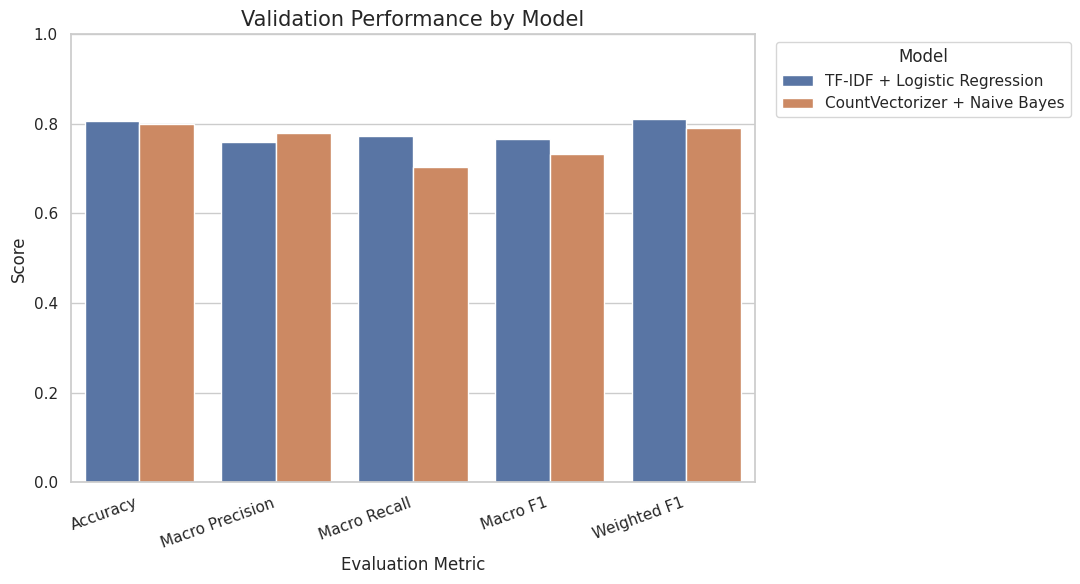

In [17]:
comparison_data = validation_results.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    var_name="Metric",
    value_name="Score"
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

sns.barplot(
    data=comparison_data,
    x="Metric",
    y="Score",
    hue="Model",
    ax=axis
)

axis.set_title(
    "Validation Performance by Model",
    fontsize=15
)

axis.set_xlabel("Evaluation Metric")
axis.set_ylabel("Score")
axis.set_ylim(0, 1)

axis.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "/content/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 24. Validation Confusion Matrices

Normalized confusion matrices reveal which sentiment classes are correctly recognized and which classes are commonly confused.

Each row represents the actual sentiment, while each column represents the predicted sentiment.

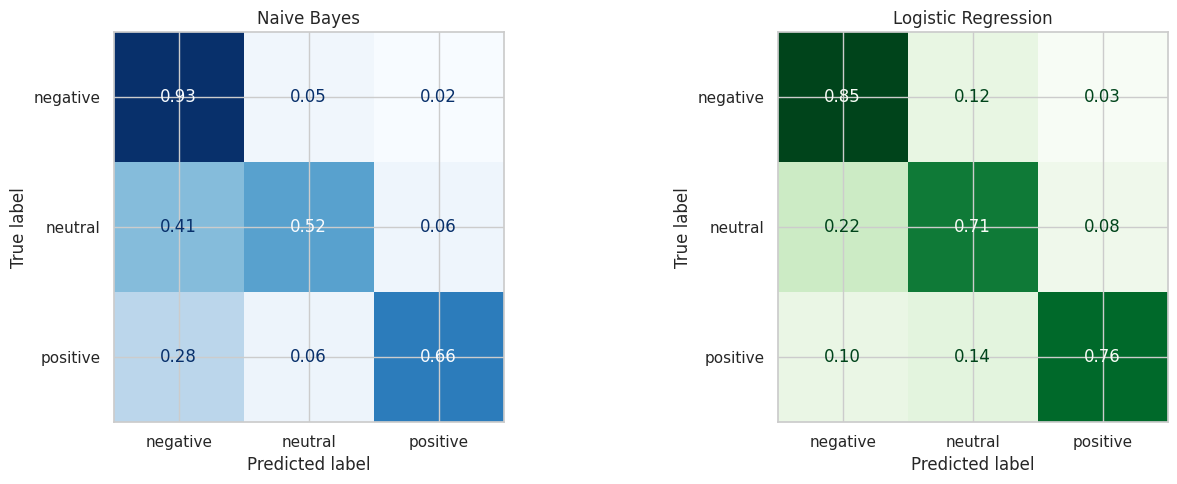

In [18]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    naive_bayes_predictions,
    labels=sentiment_order,
    display_labels=sentiment_order,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Naive Bayes"
)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_regression_predictions,
    labels=sentiment_order,
    display_labels=sentiment_order,
    normalize="true",
    values_format=".2f",
    cmap="Greens",
    colorbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "Logistic Regression"
)

plt.tight_layout()

plt.savefig(
    "/content/validation_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 25. Validation Classification Reports

The classification reports provide precision, recall, and F1-score for every sentiment class.

These class-level results help determine whether strong overall performance is hiding weak performance on the neutral or positive classes.

In [19]:
naive_bayes_report = pd.DataFrame(
    classification_report(
        y_validation,
        naive_bayes_predictions,
        labels=sentiment_order,
        output_dict=True,
        zero_division=0
    )
).transpose()

logistic_regression_report = pd.DataFrame(
    classification_report(
        y_validation,
        logistic_regression_predictions,
        labels=sentiment_order,
        output_dict=True,
        zero_division=0
    )
).transpose()

print("Naive Bayes Classification Report")

display(
    naive_bayes_report.round(4)
)

print("\nLogistic Regression Classification Report")

display(
    logistic_regression_report.round(4)
)

Naive Bayes Classification Report


,precision,recall,f1-score,support
negative,0.8160,0.9280,0.8684,1362.0000
neutral,0.7229,0.5240,0.6076,458.0000
positive,0.8021,0.6599,0.7241,344.0000
accuracy,0.7999,0.7999,0.7999,0.7999
macro avg,0.7803,0.7040,0.7334,2164.0000
weighted avg,0.7941,0.7999,0.7903,2164.0000



Logistic Regression Classification Report


,precision,recall,f1-score,support
negative,0.8953,0.8539,0.8741,1362.0000
neutral,0.6117,0.7052,0.6552,458.0000
positive,0.7745,0.7587,0.7665,344.0000
accuracy,0.8073,0.8073,0.8073,0.8073
macro avg,0.7605,0.7726,0.7653,2164.0000
weighted avg,0.8161,0.8073,0.8107,2164.0000


### Model Comparison Observation

TF-IDF with Logistic Regression was selected as the strongest model based on validation performance.

Logistic Regression achieved an accuracy of 0.8073 and a macro F1-score of 0.7653, compared with 0.7999 accuracy and 0.7334 macro F1 for Naive Bayes.

Although Naive Bayes produced slightly higher macro precision, Logistic Regression achieved considerably stronger macro recall. It also improved neutral-class recall from 0.5240 to 0.7052 and positive-class recall from 0.6599 to 0.7587.

The confusion matrices confirm that Naive Bayes is strongly biased toward the majority negative class. Logistic Regression sacrifices some negative-class recall but provides a more balanced classification of negative, neutral, and positive tweets.

Therefore, TF-IDF with Logistic Regression is the preferred model for final optimization and testing.

## 26. Logistic Regression Hyperparameter Tuning

The regularization parameter `C` controls the balance between model simplicity and fitting the training data.

Several values are evaluated using the validation set. The configuration with the strongest macro F1-score is selected.

In [20]:
def build_logistic_pipeline(c_value):
    return Pipeline([
        (
            "vectorizer",
            TfidfVectorizer(
                preprocessor=clean_text,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                max_features=30000,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                C=c_value,
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])


candidate_c_values = [
    0.5,
    1.0,
    2.0,
    4.0
]

tuning_results = []

for c_value in candidate_c_values:
    print(f"Training model with C = {c_value}...")

    candidate_model = build_logistic_pipeline(
        c_value
    )

    candidate_model.fit(
        X_train,
        y_train
    )

    candidate_predictions = candidate_model.predict(
        X_validation
    )

    candidate_metrics = calculate_metrics(
        y_validation,
        candidate_predictions,
        f"Logistic Regression C={c_value}"
    )

    candidate_metrics["C"] = c_value

    tuning_results.append(
        candidate_metrics
    )

tuning_results = pd.DataFrame(
    tuning_results
)

tuning_results = (
    tuning_results
    .sort_values(
        by="Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

best_c = float(
    tuning_results.loc[0, "C"]
)

display(
    tuning_results[
        [
            "Model",
            "C",
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1"
        ]
    ].style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

print(
    "Selected C value:",
    best_c
)

Training model with C = 0.5...
Training model with C = 1.0...
Training model with C = 2.0...
Training model with C = 4.0...


,Model,C,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression C=2.0,2.000000,0.8161,0.7705,0.7751,0.7720,0.8181
1,Logistic Regression C=0.5,0.500000,0.8091,0.7608,0.7801,0.7688,0.8131
2,Logistic Regression C=4.0,4.000000,0.8138,0.7669,0.7674,0.7664,0.8153
3,Logistic Regression C=1.0,1.000000,0.8073,0.7605,0.7726,0.7653,0.8107


Selected C value: 2.0


## 27. Final Model Training

After selecting the strongest configuration, the training and validation data are combined.

The final model is retrained using this larger development dataset before being evaluated once on the untouched test set.

In [21]:
X_development = pd.concat(
    [
        X_train,
        X_validation
    ]
)

y_development = pd.concat(
    [
        y_train,
        y_validation
    ]
)

final_model = build_logistic_pipeline(
    best_c
)

print(
    "Training the final model with C =",
    best_c
)

final_model.fit(
    X_development,
    y_development
)

final_test_predictions = final_model.predict(
    X_test
)

print("Final model training completed.")
print(
    "Development records:",
    len(X_development)
)
print(
    "Test records:",
    len(X_test)
)

Training the final model with C = 2.0
Final model training completed.
Development records: 12262
Test records: 2165


## 28. Final Test-Set Evaluation

The selected model is evaluated on the untouched test set.

These results represent the final estimate of how the system performs on previously unseen tweets.

In [22]:
final_test_results = pd.DataFrame([
    calculate_metrics(
        y_test,
        final_test_predictions,
        "Final TF-IDF + Logistic Regression"
    )
])

display(
    final_test_results.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

final_classification_report = pd.DataFrame(
    classification_report(
        y_test,
        final_test_predictions,
        labels=sentiment_order,
        output_dict=True,
        zero_division=0
    )
).transpose()

print("Final Test Classification Report")

display(
    final_classification_report.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Final TF-IDF + Logistic Regression,0.7945,0.7348,0.7480,0.7411,0.7959


Final Test Classification Report


,precision,recall,f1-score,support
negative,0.8825,0.8599,0.8711,1363.0000
neutral,0.6131,0.6318,0.6223,459.0000
positive,0.7088,0.7522,0.7298,343.0000
accuracy,0.7945,0.7945,0.7945,0.7945
macro avg,0.7348,0.7480,0.7411,2165.0000
weighted avg,0.7979,0.7945,0.7959,2165.0000


## 29. Final Test Confusion Matrix

The normalized confusion matrix shows the model's final class-level performance on previously unseen tweets.

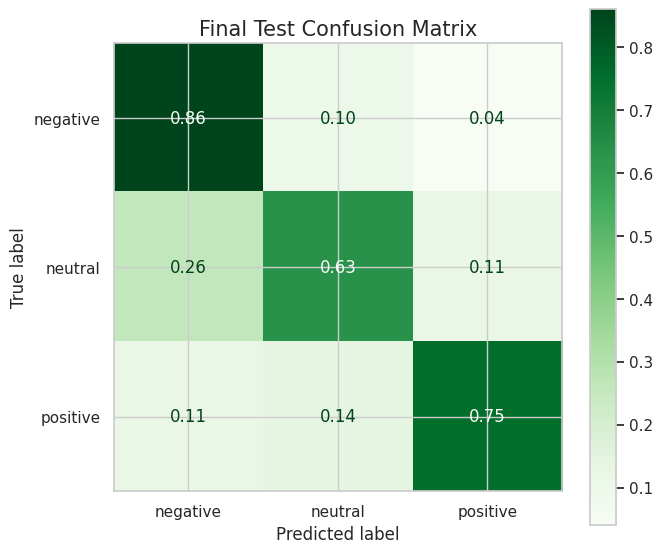

In [23]:
figure, axis = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_predictions,
    labels=sentiment_order,
    display_labels=sentiment_order,
    normalize="true",
    values_format=".2f",
    cmap="Greens",
    colorbar=True,
    ax=axis
)

axis.set_title(
    "Final Test Confusion Matrix",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "/content/final_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Final Model Performance Observation

Hyperparameter tuning selected `C = 2.0` as the strongest Logistic Regression configuration. It achieved validation accuracy of 0.8161 and macro F1-score of 0.7720.

After retraining on the combined training and validation data, the final model achieved test accuracy of 0.7945, macro F1-score of 0.7411, and weighted F1-score of 0.7959.

Negative sentiment produced the strongest class-level performance, with precision of 0.8825, recall of 0.8599, and F1-score of 0.8711. Positive sentiment achieved an F1-score of 0.7298, while neutral sentiment was the most difficult class, with an F1-score of 0.6223.

The confusion matrix shows that 86% of negative tweets, 63% of neutral tweets, and 75% of positive tweets were classified correctly. Neutral tweets were most frequently confused with negative tweets, which reflects the linguistic overlap between factual complaints and explicitly negative opinions.

The test results are slightly lower than the validation results, representing a normal generalization difference on previously unseen data. Overall, the model provides strong and reasonably balanced performance for a classical TF-IDF sentiment-classification system.

## 30. Error Analysis

Incorrect test predictions are examined to understand the model's limitations.

The analysis includes the actual label, predicted label, prediction confidence, and original tweet. High-confidence mistakes are especially important because they show cases where the model was confidently incorrect.

In [24]:
test_probabilities = final_model.predict_proba(
    X_test
)

class_names = (
    final_model
    .named_steps["classifier"]
    .classes_
)

test_results = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual_sentiment": y_test.reset_index(drop=True),
    "predicted_sentiment": final_test_predictions,
    "prediction_confidence": test_probabilities.max(
        axis=1
    )
})

for class_index, class_name in enumerate(
    class_names
):
    test_results[
        f"probability_{class_name}"
    ] = test_probabilities[:, class_index]

test_results["correct_prediction"] = (
    test_results["actual_sentiment"]
    == test_results["predicted_sentiment"]
)

incorrect_predictions = (
    test_results[
        ~test_results["correct_prediction"]
    ]
    .sort_values(
        by="prediction_confidence",
        ascending=False
    )
)

error_count = len(
    incorrect_predictions
)

error_percentage = (
    error_count
    / len(test_results)
    * 100
)

print("Total test predictions:", len(test_results))
print("Incorrect predictions:", error_count)
print(f"Test error rate: {error_percentage:.2f}%")

print("\nHigh-confidence incorrect predictions:")

display(
    incorrect_predictions[
        [
            "text",
            "actual_sentiment",
            "predicted_sentiment",
            "prediction_confidence"
        ]
    ]
    .head(15)
    .style.format({
        "prediction_confidence": "{:.2%}"
    })
)

Total test predictions: 2165
Incorrect predictions: 445
Test error rate: 20.55%

High-confidence incorrect predictions:


,text,actual_sentiment,predicted_sentiment,prediction_confidence
263,@AmericanAir 48 hours and still no bag. Could have flown to Costa Rica and back by now. I had gifts for my family in my bags.,neutral,negative,97.39%
1579,@JetBlue #jetblue #sofly #wish #firststari seetonight http://t.co/pyJAoayNx6,neutral,positive,96.63%
839,@VirginAmerica BIG Love/gratitude.mpower w/ http://t.co/1AGR9knCpf weRin #OSCARS2105 VIPswagbags@ #AvalonHollywood http://t.co/ybMbGs0dHn,neutral,positive,96.35%
149,@united big up the pilot of 644 for turning 1hr on the tarmac to just a 20min delayed arrival,positive,negative,94.90%
414,@JetBlue Does @AirCanada not take fraud as seriously?,neutral,negative,94.32%
704,@united will do. Thank you!,neutral,positive,93.08%
1272,@SouthwestAir will do. Thank you.,neutral,positive,93.08%
1213,@AmericanAir #oaaret is our flight Cancelled Flightled?,neutral,negative,92.71%
1659,@JetBlue where is it coming from? I thought Tampa?,negative,neutral,92.09%
1030,@united Thanks. Got it straightend out last night.,neutral,positive,91.32%


## 31. Error-Type Distribution

The incorrect predictions are grouped by their actual and predicted classes. This identifies the most common type of sentiment confusion.

,actual_sentiment,predicted_sentiment,error_count
0,negative,neutral,136
2,neutral,negative,118
1,negative,positive,55
3,neutral,positive,51
5,positive,neutral,47
4,positive,negative,38


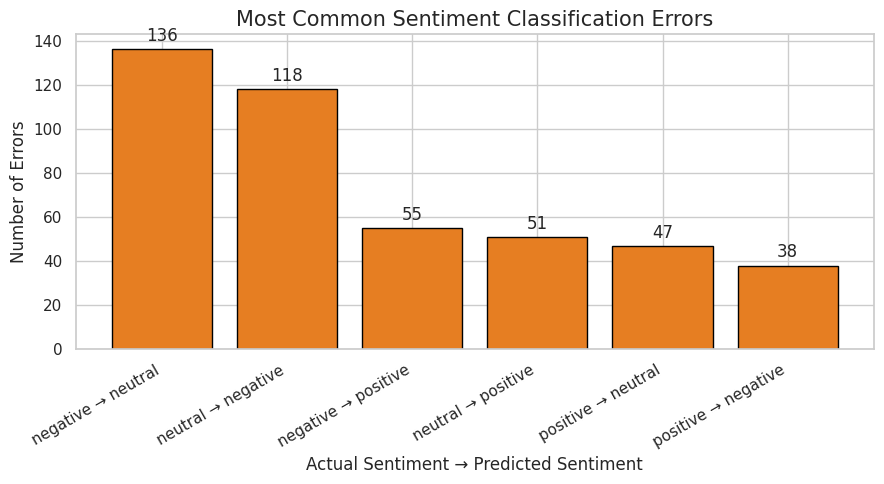

In [25]:
error_type_summary = (
    incorrect_predictions
    .groupby(
        [
            "actual_sentiment",
            "predicted_sentiment"
        ]
    )
    .size()
    .reset_index(
        name="error_count"
    )
    .sort_values(
        by="error_count",
        ascending=False
    )
)

display(
    error_type_summary
)

figure, axis = plt.subplots(
    figsize=(9, 5)
)

error_labels = (
    error_type_summary["actual_sentiment"]
    + " → "
    + error_type_summary["predicted_sentiment"]
)

bars = axis.bar(
    error_labels,
    error_type_summary["error_count"],
    color="#E67E22",
    edgecolor="black"
)

axis.bar_label(
    bars,
    padding=3
)

axis.set_title(
    "Most Common Sentiment Classification Errors",
    fontsize=15
)

axis.set_xlabel(
    "Actual Sentiment → Predicted Sentiment"
)

axis.set_ylabel(
    "Number of Errors"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "/content/error_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 32. Most Influential Sentiment Features

The Logistic Regression coefficients are examined to identify the words and phrases most strongly associated with each sentiment class.

A larger positive coefficient means the feature contributes more strongly toward predicting that class.

In [26]:
final_vectorizer = (
    final_model
    .named_steps["vectorizer"]
)

final_classifier = (
    final_model
    .named_steps["classifier"]
)

feature_names = np.array(
    final_vectorizer.get_feature_names_out()
)

number_of_features = 15

influential_feature_tables = {}

for class_index, class_name in enumerate(
    final_classifier.classes_
):
    class_coefficients = (
        final_classifier.coef_[class_index]
    )

    strongest_indices = np.argsort(
        class_coefficients
    )[-number_of_features:][::-1]

    feature_table = pd.DataFrame({
        "Feature": feature_names[
            strongest_indices
        ],
        "Coefficient": class_coefficients[
            strongest_indices
        ]
    })

    influential_feature_tables[
        class_name
    ] = feature_table

    print(
        f"Most influential features for {class_name}:"
    )

    display(
        feature_table.style.format({
            "Coefficient": "{:.4f}"
        })
    )

Most influential features for negative:


,Feature,Coefficient
0,not,6.1843
1,no,4.7270
2,delayed,4.6027
3,hours,4.3508
4,worst,3.4018
5,why,3.3958
6,hour,3.2530
7,hrs,3.2298
8,cancelled,3.1919
9,your,3.1561


Most influential features for neutral:


,Feature,Coefficient
0,can,3.3277
1,is there,2.5750
2,is your,2.0831
3,do you,1.9569
4,do,1.9048
5,if,1.9010
6,dm,1.8928
7,is flight,1.8888
8,is it,1.8867
9,can you,1.8605


Most influential features for positive:


,Feature,Coefficient
0,great,6.9991
1,thanks,5.9413
2,love,5.3054
3,awesome,5.1583
4,thank,4.0991
5,amazing,4.0362
6,thx,3.5701
7,best,3.5201
8,appreciate,3.2572
9,excellent,3.0468


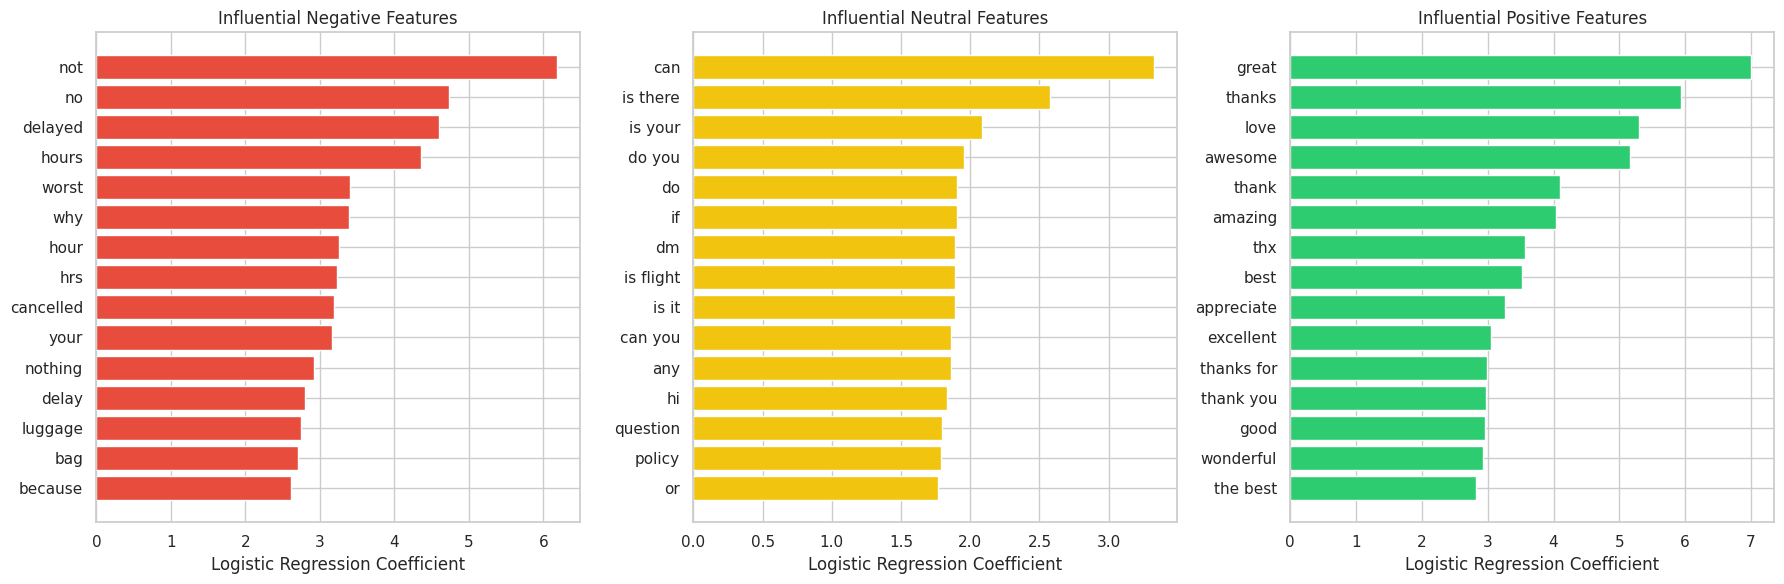

In [27]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for axis, class_name in zip(
    axes,
    final_classifier.classes_
):
    feature_table = influential_feature_tables[
        class_name
    ].sort_values(
        by="Coefficient"
    )

    axis.barh(
        feature_table["Feature"],
        feature_table["Coefficient"],
        color=sentiment_colors[class_name]
    )

    axis.set_title(
        f"Influential {class_name.title()} Features"
    )

    axis.set_xlabel(
        "Logistic Regression Coefficient"
    )

plt.tight_layout()

plt.savefig(
    "/content/influential_sentiment_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 33. Command-Line Sentiment Predictor

The command-line interface accepts custom text and displays the predicted sentiment, confidence score, and probability assigned to every class.

The user can continue entering text until `exit` is entered.

In [28]:
def predict_sentiment(input_text):
    if not isinstance(input_text, str):
        raise TypeError(
            "The input must be a text string."
        )

    input_text = input_text.strip()

    if not input_text:
        raise ValueError(
            "The input text cannot be empty."
        )

    predicted_sentiment = final_model.predict(
        [input_text]
    )[0]

    predicted_probabilities = (
        final_model.predict_proba(
            [input_text]
        )[0]
    )

    probability_results = {
        class_name: float(probability)
        for class_name, probability in zip(
            class_names,
            predicted_probabilities
        )
    }

    confidence = probability_results[
        predicted_sentiment
    ]

    return {
        "text": input_text,
        "sentiment": predicted_sentiment,
        "confidence": confidence,
        "probabilities": probability_results
    }


def run_sentiment_cli():
    print("Sentiment Analysis Tool")
    print("Enter 'exit' to close the program.\n")

    while True:
        user_text = input(
            "Enter text for sentiment analysis: "
        )

        if user_text.strip().lower() == "exit":
            print("Sentiment analysis closed.")
            break

        try:
            result = predict_sentiment(
                user_text
            )

            print(
                "\nPredicted sentiment:",
                result["sentiment"].title()
            )

            print(
                f"Confidence: "
                f"{result['confidence']:.2%}"
            )

            print("Class probabilities:")

            for sentiment, probability in (
                result["probabilities"].items()
            ):
                print(
                    f"  {sentiment.title()}: "
                    f"{probability:.2%}"
                )

            print()

        except (
            ValueError,
            TypeError
        ) as error:
            print("Error:", error)
            print()

In [30]:
run_sentiment_cli()

Sentiment Analysis Tool
Enter 'exit' to close the program.

Enter text for sentiment analysis: exit
Sentiment analysis closed.


In [31]:
sentiment_emojis = {
    "positive": "😊",
    "neutral": "😐",
    "negative": "😞"
}

sentiment_messages = {
    "positive": "This text expresses a positive sentiment.",
    "neutral": "This text expresses a neutral sentiment.",
    "negative": "This text expresses a negative sentiment."
}


def run_sentiment_cli():
    print("=" * 50)
    print("Sentiment Analysis Tool")
    print("Enter 'exit' to close the program.")
    print("=" * 50)

    while True:
        user_text = input(
            "\nEnter text for sentiment analysis: "
        )

        if user_text.strip().lower() == "exit":
            print("\nSentiment analysis closed.")
            print("Thank you for using the tool.")
            break

        try:
            result = predict_sentiment(
                user_text
            )

            predicted_sentiment = result[
                "sentiment"
            ]

            emoji = sentiment_emojis[
                predicted_sentiment
            ]

            message = sentiment_messages[
                predicted_sentiment
            ]

            print("\n" + "-" * 50)

            print(
                f"Result: {emoji} "
                f"{predicted_sentiment.title()}"
            )

            print(message)

            print("-" * 50)

        except (
            ValueError,
            TypeError
        ) as error:
            print(
                "\nUnable to analyze the text:",
                error
            )

In [33]:
run_sentiment_cli()\

Sentiment Analysis Tool
Enter 'exit' to close the program.

Enter text for sentiment analysis: it was good first but at the end, the worst like a nightmare

--------------------------------------------------
Result: 😞 Negative
This text expresses a negative sentiment.
--------------------------------------------------

Enter text for sentiment analysis: how can they be so bad

--------------------------------------------------
Result: 😐 Neutral
This text expresses a neutral sentiment.
--------------------------------------------------

Enter text for sentiment analysis: veryy wow

--------------------------------------------------
Result: 😊 Positive
This text expresses a positive sentiment.
--------------------------------------------------

Enter text for sentiment analysis: the food is served at 11

--------------------------------------------------
Result: 😞 Negative
This text expresses a negative sentiment.
--------------------------------------------------

Enter text for sentimen